> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API
%pip install -q coptpy


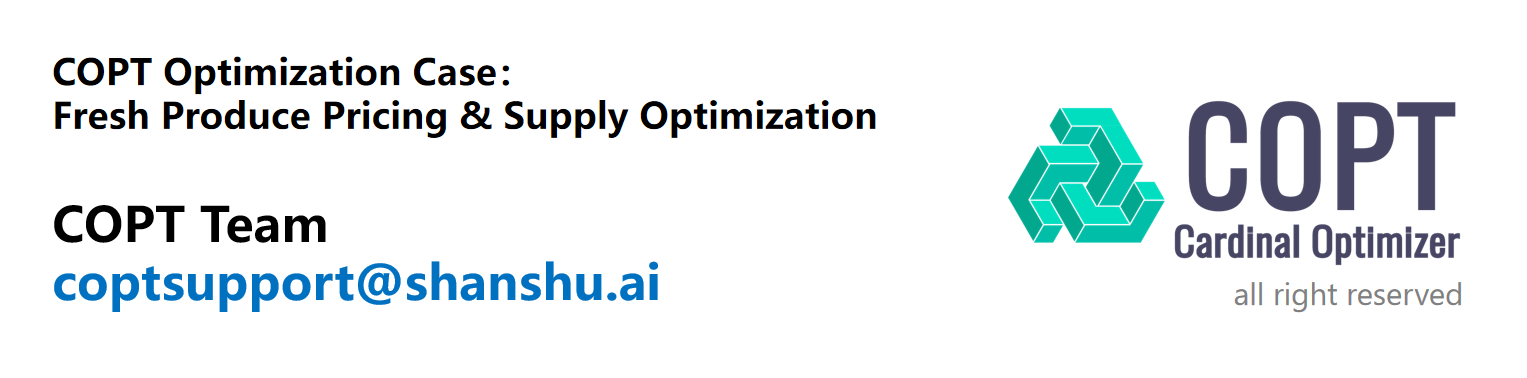

# Fresh Produce Pricing & Supply Optimization

## Steps for Solving the Optimization Problem Using COPT Modeling 
### Preparation Phase: Dataset Generation and Preprocessing 
### Part One: Descriptive Analysis 
1. **Selecting national overall data analysis**
- **Monthly sales changes**
- **Seasonal analysis**

### Part Two: Predictive Analysis 
1. **Dataset Splitting**: 80% for training set and 20% for test set 
2. **Constructing the OLS Regression Model** 
3. **Output Regression Results** 
4. **Calculate the R² indicator**

### Part Three: Decision-making Analysis 
1. **Import the COPT-Python interface library** `coptpy` 
2. **Create the COPT solution environment and model** 
3. **Model Construction: Add the Three Elements Sequentially**
- **Decision Variables**:
  - $\text{price}_r$: The sales price of region $r$. This is a continuous variable representing the unit price of the goods set for that region within a given range.
  - $\text{num}_r$: The quantity of goods allocated to region $r$. This is a continuous variable representing the number of goods from the total inventory allocated to region $r$.
  - $\text{supply}_r$: The actual sales quantity of region $r$. This is an auxiliary variable representing the number of goods that region $r$ can actually sell at the given price and allocation quantity.
  - $\text{waste}_r$: The quantity of goods wasted in region $r$. This is an auxiliary variable representing the waste quantity resulting from allocating to region $r$ but failing to sell.
  - $\text{c}_{\text{waste}}$: The cost per unit of wasted goods.
  - $\text{c}^{r}_{\text{transport}}$: The transportation cost for allocating to region $r$.
- **Objective Function**: Maximize the total net revenue of all regions.
- **Constraints**:
  A. Supply Quantity Constraint
  B. Sales Quantity Constraint
  C. Waste Quantity Constraint 
4. **Solve** 
5. Review and analyze the results

## Load dependencies and datasets 

Next, we will load some Python packages that are used for data analysis and visualization.

In [8]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn import tree 
import seaborn as sns
import sklearn 
import numpy as np  
import coptpy as cp
from coptpy import COPT

In [9]:
# Set a random seed
rng = np.random.default_rng(42)

# China Region
regions = ["EastChina", "NorthChina", "SouthChina", "Southwest", "CentralChina"]

# Product Type
types = ["Domestic", "Imported"]

# Weekly Dates for 2020–2025 (Generated on a Weekly Basis)
dates = pd.date_range("2020-01-05", "2025-12-28", freq="7D")

rows = []

for d in dates:
    month = d.month

    # ---- Seasonal Factors ----
    if month in [7, 8]:
        season_factor = 1.70
    elif month in [4, 5, 6, 9, 10]:
        season_factor = 1.20
    else:
        season_factor = 0.60


    for r in regions:

        # ---- Regional Baseline Demand Variations ----
        if r in ["EastChina", "SouthChina"]:
            region_demand_base = 520000
            region_price_shift = 0.28
        elif r == "CentralChina":
            region_demand_base = 450000
            region_price_shift = 0.18
        else:  # NorthChina, Southwest
            region_demand_base = 380000
            region_price_shift = 0.10

        for t in types:

            # ---- Type Differences (Domestic vs Imported) ----
            if t == "Imported":
                type_price_base = 5.2
                type_demand_factor = 0.85
            else:
                type_price_base = 4.3
                type_demand_factor = 1.0

            # ---- Random Price (Limited to 2 - 8 Yuan)----
            price = (
                type_price_base
                + region_price_shift
                + rng.normal(loc=0.0, scale=0.30)
            )
            price = max(2.0, min(price, 8.0))

            # ---- Sales Model (Decreases as Price Drops) ----
            demand_base = region_demand_base * season_factor * type_demand_factor

            units = (
                demand_base * (1 - 0.25 * (price - 4.8)) 
                + rng.normal(loc=0, scale=45000)
            )
            

            units = max(60000, units)  # To prevent it from being too low

            rows.append({
                "region": r,
                "date": d,
                "type": t,
                "price": round(float(price), 4),
                "units_sold": float(units),
            })

df = pd.DataFrame(rows)

# Show the first ten lines to view the data structure
df.head(10)

,region,date,type,price,units_sold
0,EastChina,2020-01-05,Domestic,4.6714,275230.335553
1,EastChina,2020-01-05,Imported,5.7051,247514.937953
2,NorthChina,2020-01-05,Domestic,3.8147,225564.623917
3,NorthChina,2020-01-05,Imported,5.3384,153485.923085
4,SouthChina,2020-01-05,Domestic,4.5750,291166.170345
5,SouthChina,2020-01-05,Imported,5.7438,237625.411374
6,Southwest,2020-01-05,Domestic,4.4198,300396.729385
7,Southwest,2020-01-05,Imported,5.4403,124111.590881
8,CentralChina,2020-01-05,Domestic,4.5906,240983.079585
9,CentralChina,2020-01-05,Imported,5.6435,178855.508194


## Data Preprocessing
First, two new feature columns, "year" and "seasonality", are added to the original DataFrame. Second, since the data covers the period from 2020 to 2025, the years are mapped to integer indices in chronological order to facilitate processing..
 
Furthermore, based on the consumption patterns of daily fresh goods, we define **June to August as the peak season**, while the remaining months are considered as the off-season. The peak season typically corresponds to increased demand and greater supply fluctuations, making it highly suitable as a seasonal factor in the regression model.

In [14]:
df["year"] = pd.to_datetime(df["date"]).dt.year
df["year_index"] = df["year"] - df["year"].min()

df["month"] = pd.to_datetime(df["date"]).dt.month
df["peak"] = df["month"].isin([6,7,8]).astype(int)
df.head(10) 

,region,date,type,price,units_sold,year,year_index,month,peak
0,EastChina,2020-01-05,Domestic,4.6714,275230.335553,2020,0,1,0
1,EastChina,2020-01-05,Imported,5.7051,247514.937953,2020,0,1,0
2,NorthChina,2020-01-05,Domestic,3.8147,225564.623917,2020,0,1,0
3,NorthChina,2020-01-05,Imported,5.3384,153485.923085,2020,0,1,0
4,SouthChina,2020-01-05,Domestic,4.5750,291166.170345,2020,0,1,0
5,SouthChina,2020-01-05,Imported,5.7438,237625.411374,2020,0,1,0
6,Southwest,2020-01-05,Domestic,4.4198,300396.729385,2020,0,1,0
7,Southwest,2020-01-05,Imported,5.4403,124111.590881,2020,0,1,0
8,CentralChina,2020-01-05,Domestic,4.5906,240983.079585,2020,0,1,0
9,CentralChina,2020-01-05,Imported,5.6435,178855.508194,2020,0,1,0


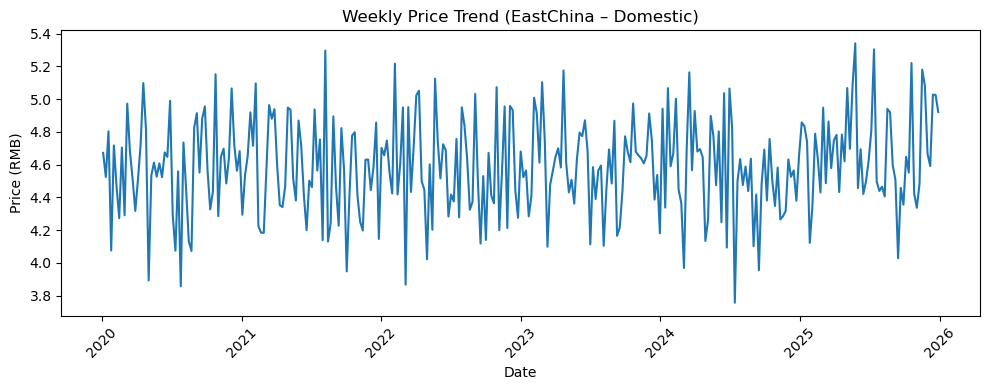

In [16]:
# Select a specific region and product type, such as EastChina + Domestic
df_region_type = df[(df["region"] == "EastChina") & (df["type"] == "Domestic")]

# Sort by Date
df_sorted = df_region_type.sort_values("date")

# Price Trend Chart
plt.figure(figsize=(10, 4))
plt.plot(df_sorted["date"], df_sorted["price"])
plt.xlabel("Date")
plt.ylabel("Price (RMB)")
plt.title("Weekly Price Trend (EastChina – Domestic)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
# Parsing Date
df['date'] = pd.to_datetime(df['date'])

# Extract the year
df['year'] = df['date'].dt.year

# Map the years to 2024→0, 2025→1 
df['year_index'] = df['year'] - df['year'].min()

# Sort by Time
df = df.sort_values(by='date')

# Extract the month
df['month'] = df['date'].dt.month

# Define Peak Season (June - August) 
peak_months = [6, 7, 8]
df['peak'] = df['month'].isin(peak_months).astype(int)

# # Optional: Scale sales (This can be used if the values of the subsequent optimized model are relatively large) 
df['units_sold'] = df['units_sold'] / 1000000

# f only the analysis is conducted for a specific product type, such as Domestic:
# df = df[df['type'] == 'Domestic']

# Keep the required fields
df = df[['date','units_sold','price','region','year','month','year_index','peak','type']].reset_index(drop=True)

df.head()


,date,units_sold,price,region,year,month,year_index,peak,type
0,2020-01-05,0.275230,4.6714,EastChina,2020,1,0,0,Domestic
1,2020-01-05,0.247515,5.7051,EastChina,2020,1,0,0,Imported
2,2020-01-05,0.225565,3.8147,NorthChina,2020,1,0,0,Domestic
3,2020-01-05,0.153486,5.3384,NorthChina,2020,1,0,0,Imported
4,2020-01-05,0.291166,4.5750,SouthChina,2020,1,0,0,Domestic


# Part One: Descriptive Analysis 

Next, we will analyze the changes in sales data over time and determine if there are any obvious seasonal patterns.
To make the analysis more intuitive, we first select the **national overall data** (i.e., the aggregated trend across all regions) for an initial exploration. 

By observing the overall trends of prices and sales volumes, we can understand the changes of this fresh produce in different months and years, and provide a basis for the subsequent demand prediction model.

In [21]:
# Calculate the overall average price and total sales volume (aggregated by date) for the entire country
df_total = df.groupby('date', as_index=False).agg({
    'price': 'mean',
    'units_sold': 'sum'
})

In [23]:
df_total.head()

,date,price,units_sold
0,2020-01-05,4.99426,2.274934
1,2020-01-12,5.02384,2.340526
2,2020-01-19,4.90697,2.592851
3,2020-01-26,4.87338,2.486262
4,2020-02-02,4.83422,2.314955


## Monthly sales fluctuations

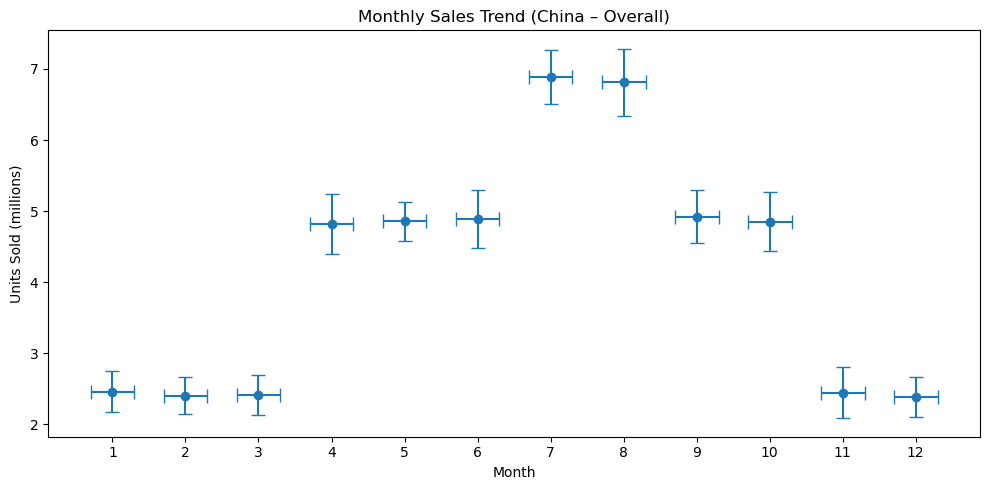

In [26]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

# Add the month column
df_total['month'] = pd.to_datetime(df_total['date']).dt.month

# Statistics of the average and standard deviation of national sales volume by month 
mean = df_total.groupby('month')['units_sold'].mean()
std  = df_total.groupby('month')['units_sold'].std()

# Draw error bar graph (mean ± 2× standard deviation)
axes.errorbar(mean.index, mean, xerr=0.3, yerr=2*std, fmt='o', capsize=5)

axes.set_ylabel('Units Sold (millions)')
axes.set_xlabel('Month')
axes.set_title('Monthly Sales Trend (China – Overall)')

axes.set_xticks(range(1, 13))  #  Display months from 1 to 12 

fig.tight_layout()
plt.show()


It can be observed that the sales volume of fresh goods has generally been on the rise over the years, although the growth rate is not significant. 

The decline in sales that occurred in 2019 was related to the widely reported shortage of fresh goods supply in 2019 – this event led to a nearly doubling of the prices of fresh goods.

## Seasonal Analysis 

Next, we will continue to observe the changing trend of sales within a year, that is, the seasonal characteristics of sales; analyzing by month will enable a clearer presentation of peak consumption periods, off-peak seasons, and possible cyclical patterns.

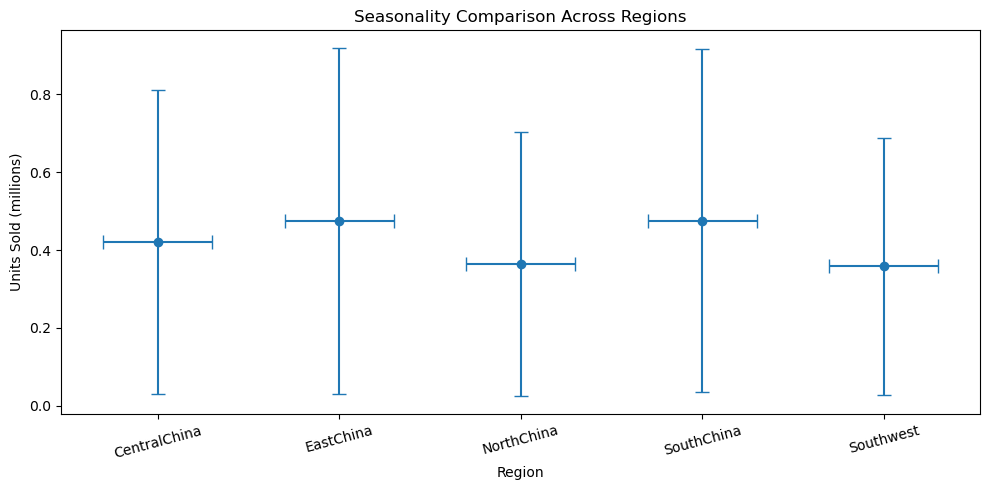

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

regions = ["EastChina", "NorthChina", "SouthChina", "Southwest", "CentralChina"]

# Ensure that there is a "month" column
df['month'] = pd.to_datetime(df['date']).dt.month

# For each region: Calculate the mean (seasonal average) and standard deviation of sales for all months
mean = df.groupby('region')['units_sold'].mean()
std  = df.groupby('region')['units_sold'].std()

# Draw error bar graph
axes.errorbar(
    range(len(mean)), 
    mean, 
    xerr=0.3, 
    yerr=2*std, 
    fmt='o', 
    capsize=5
)

plt.xlabel("Region")
plt.ylabel("Units Sold (millions)")
plt.title("Seasonality Comparison Across Regions")

# Set the label for the horizontal axis
plt.xticks(
    range(len(mean)), 
    mean.index, 
    rotation=15
)

plt.tight_layout()
plt.show()


# Part Two: Predictive Analysis 

Now we use the features constructed in the previous section to conduct a regression model for sales volume.
To test the generalization ability of the model, we randomly divide the complete dataset into an **80% training set** and a **20% test set**. 

This example employs the most common ordinary least squares regression (OLS). The model includes: 

- $\text{price}_r$: The price of goods in region $r$  
- $\text{year\_index}$: The sequential code for the year, used to capture the overall annual trend 
- $\text{c}_\text{region}$: The categorical variable corresponding to different regions
- $\text{peak}$: The indicator variable for peak season (e.g., 6–8 months is 1, the rest is 0) 

The well-fitted model can predict the corresponding sales volume (predicted demand) for any given set of (price, region, year, season). Linear regression can be expressed as: 

$$
d(\text{price}_r,\, r) = \beta_0 
+ \beta_1 \cdot \text{price}_r
+ \sum_{r\in\text{R}} \beta_2^{r} \cdot \mathbf{1}_{\text{region}}
+ \beta_3 \cdot \text{year\_index}
+ \beta_4 \cdot \mathbf{1}_{\text{peak}}
$$

Among them: 
- $\beta$ represents the regression coefficients that the model needs to learn;
- $\mathbf{1}_{\text{region}}$: is an indicator variable for the region, with each region corresponding to a 0/1 label;
- $\text{year\_index}$ is the sequential code for the year (for example, 2020 → 0, 2021 → 1, and so on);
- $\mathbf{1}_{\text{peak}}$: indicates whether it is in the peak season (for example, June–August), with 1 indicating the peak season and 0 otherwise. 

To evaluate the model's performance, we randomly divided the data into an **80% training set** and a **20% test set**, and used the linear regression tool provided by sklearn to fit these parameters. 

The code implementation follows these steps:
1. Dataset splitting
2. Model fitting using the training set
3. Outputting the summary of regression coefficients
4. Calculating the R² metric on the test set to evaluate the model's predictive performance on unseen data

In [33]:
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Divide the training set and the test set
df_train, df_test = train_test_split(df, train_size=0.8, random_state=1)

# 2. Build an OLS regression model
formula = 'units_sold ~ price + year_index + C(region) + peak'
model = smf.ols(formula=formula, data=df_train)
result = model.fit()

# 3. Output regression results
print(result.summary())

# 4. Test set R²
y_true = df_test['units_sold']
y_pred = result.predict(df_test)
print("Test R²:", r2_score(y_true, y_pred))


                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     502.6
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:10:31   Log-Likelihood:                 1533.8
No. Observations:                2504   AIC:                            -3052.
Df Residuals:                    2496   BIC:                            -3005.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [35]:
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score

# Use EastChina as the baseline
formula = 'units_sold ~ price + year_index + C(region, Treatment(reference="EastChina")) + peak'

mod_full = smf.ols(formula=formula, data=df)
result_full = mod_full.fit()

y_true_full = df['units_sold']
y_pred_full = result_full.predict(df)

print("The R^2 value in the full dataset is", r2_score(y_true_full, y_pred_full))

coef_dict = result_full.params.to_dict()
coef_dict

The R^2 value in the full dataset is 0.5821639691660185


{'Intercept': 1.2260585668685309,
 'C(region, Treatment(reference="EastChina"))[T.CentralChina]': -0.07132362930407651,
 'C(region, Treatment(reference="EastChina"))[T.NorthChina]': -0.1419842932835118,
 'C(region, Treatment(reference="EastChina"))[T.SouthChina]': 0.0007454305157608004,
 'C(region, Treatment(reference="EastChina"))[T.Southwest]': -0.14621482800069435,
 'price': -0.162331102379062,
 'year_index': -0.0009270836776584209,
 'peak': 0.26955485004449303}

$$
d(\text{price}_r,\, r) = \beta_0 
+ \beta_1 \cdot \text{price}_r
+ \sum_{r\in\text{R}} \beta_2^{r} \cdot \mathbf{1}_{\text{region}}
+ \beta_3 \cdot \text{year\_index}
+ \beta_4 \cdot \mathbf{1}_{\text{peak}}
$$

In this equation, except for the decision variable $\text{price}_r$, all the other coefficients have been determined through OLS fitting. They can be substituted as constants in the subsequent optimization model calculation process.

# Part Three: Decision-making Analysis

The previous prediction section has already established a regression model capable of predicting sales volume, which can estimate future demand based on factors such as price, region, year, and seasonality. Next, this case will combine the prediction model with the mathematical optimization model, and invoke the COPT solver to solve the problem of how to set prices and allocate goods to achieve the maximum profit under the condition of limited inventory. Through this part, a complete "from data to decision" process can be achieved. 

In the actual fresh food retail scenarios, merchants usually encounter the following problems:

- **The price is set too high**: The profit per unit is high, but the sales volume decreases;
- **The price is set too low**: The sales volume increases, but the revenue may not be the maximum;
- **The supply is limited**: How to distribute it among multiple regions?
- **The transportation and waste costs** cannot be ignored;
- **The peak and off-peak seasons** have different impacts on different regions.


## Import the COPT-Python interface library

In [67]:
import coptpy as cp
from coptpy import COPT

## Create the solution environment and the solution model

In [70]:
env = cp.Envr()
m = env.createModel("Fresh_Product_Price_Allocation")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



In [72]:
# Sets and Parameters
R = regions   # The collection of all regions, such as ["East China", "North China", ...]
Cap = 5.0       # Total supply volume (unit: millions of fresh goods)

peak_or_not = 1      # 1 indicates peak season, 0 indicates off-season.
year = 2023          

# Waste cost (unit: yuan per piece, corresponding to the dimensional scaling of yuan per million pieces in the model)
c_waste = 0.2

# Transportation costs for each region (unit: yuan per piece)
c_transport = {
    "EastChina":   0.08,
    "NorthChina":  0.10,
    "SouthChina":  0.06,
    "CentralChina":0.09,
    "Southwest":   0.12,
}

# Obtain the upper and lower bounds of prices and supply quantities from the data
# Price range: For example, limited to within the range of [3, 10] yuan
price_min = {r: 3.0 for r in R}   # The minimum price of region r
price_max = {r: 10.0 for r in R}  # The maximum price of region r

# Supply quantity bounds: Use historical sales volume (already scaled by millions) as the "reasonable range"
supply_min = dict(df.groupby("region")["units_sold"].min())  # Minimum supply quantity per region (in millions)
supply_max = dict(df.groupby("region")["units_sold"].max())  # Maximum supply quantity for each region (in millions)


## Add the Three Elements of the Model 

### Add decision variables

In this model, we aim to make decisions regarding the pricing and allocation quantity for each region, and it is also necessary to explicitly describe "how much is expected to be sold" and "how much is expected to be wasted".
For each region $r \in \text{R}$, let: 

- $\text{price}_r$ : The unit price (in yuan) of fresh goods in region $r$;
- $\text{num}_r$ : The quantity (in the same unit as the previous text, for example "million pieces") allocated to region $r$.
- $\text{supply}_r = \min \{\text{num}_r,\; d(\text{price}_r,\, r)\}$ : The predicted quantity of fresh goods that can be sold in region $r$; 
- $\text{waste}_r = \text{num}_r - \text{supply}_r$ : The predicted quantity of fresh goods that will be wasted in region $r$.

In [75]:
# excess wasteage in each region
price = m.addVars(R,lb=price_min, ub=price_max, nameprefix="p")   
num = m.addVars(R,lb=supply_min, ub=supply_max, nameprefix="x")  
supply = m.addVars(R,lb=0, nameprefix="s")   
waste = m.addVars(R,lb=0, nameprefix="w")   

$$
d(\text{price}_r,\, r) = \beta_0 
+ \beta_1 \cdot \text{price}_r
+ \sum_{r\in\text{R}} \beta_2^{r} \cdot \mathbf{1}_{\text{region}}
+ \beta_3 \cdot \text{year\_index}
+ \beta_4 \cdot \mathbf{1}_{\text{peak}}
$$

In the demand forecasting function, except for the price, other parameters (such as region, year and seasonality) are not decision variables and can thus be treated as constants.

In [78]:
d = {}

for r in R:
    # Starting from the intercept point
    expr = coef_dict["Intercept"]

    # Price item: beta_price * p_r
    expr += coef_dict["price"] * price[r]

    # Regional dummy item: If the key does not exist, it indicates that it is the base region and the coefficient is 0.
    region_key = f"C(region)[T.{r}]"
    if region_key in coef_dict:
        expr += coef_dict[region_key]
    # Otherwise, it is the baseline and does not require any additional information.

    # Year column: year_index = year - 2020 (The data range is from 2020 to 2025)
    expr += coef_dict["year_index"] * (year - 2020)

    # Peak season item
    expr += coef_dict["peak"] * peak_or_not

    d[r] = expr

### Set the objective function 

Next, let's define the objective function: We aim to **maximize the total net revenue across all regions**. 

The sales revenue of each region is obtained by multiplying the "unit price of fresh goods in that region" by the "quantity sold in that region".
In terms of costs, two types of costs are considered: 

1. The waste cost resulting from unsold and wasted fresh goods;
2. The transportation cost for delivering fresh goods to various regions;
3. The remaining costs are assumed to be fixed costs and are not included in the objective function for consideration.

**Net Income Composition**: Sales Revenue - Cost of Product Waste - Transportation Cost 
The formula for calculating net income is as follows:

$$
    \max \; \sum_{r \in \text{R}} \Big(\text{price}_r \, \text{supply}_r - \text{c}_{\text{waste}} \, \text{waste}_r - \text{c}^{r}_{\text{transport}} \, \text{num}_r \Big)
$$


In [81]:
m.setObjective(cp.quicksum(price[r]*supply[r] - c_waste*waste[r] - c_transport[r]*num[r] for r in R), sense=COPT.MAXIMIZE) 

### Adding Constraint Conditions
1. **Supply Quantity Constraint**: This constraint is used to ensure that the total quantity of fresh goods allocated to each region must be equal to the given total supply quantity $Cap$.
$$
    \sum_{r \in \text{R}} \text{num}_r = \text{Cap}
$$

In [84]:
m.addConstr(cp.quicksum(num[r] for r in R) == Cap)

<coptpy.Constraint: >

2. **Sales Quantity Constraints**: Add constraints to depict the predicted sales quantities for each region.

- If the supply quantity is greater than the predicted demand quantity, then the actual sales volume is equal to the predicted demand quantity;
- If the supply quantity is less than or equal to the predicted demand quantity, then the actual sales volume is equal to the supply quantity.
- 
Therefore, the predicted sales volume for region $r$ can be expressed as the smaller value of the two:

$$
    \text{supply}_r \leq \min \{\text{num}_r,\, d(\text{price}_r,\, r)\}, \quad \forall\, r\in \text{R}
$$

This relationship can be expressed by adding the following two sets of inequalities to each region $r$:

$$
\begin{aligned}
    \text{supply}_r &\leq \text{num}_r, \\
    \text{supply}_r &\leq d(\text{price}_r,\, r), \quad \forall\, r\in \text{R}
\end{aligned}
$$


In [87]:
m.addConstrs((supply[r] <= num[r] for r in R))
m.addConstrs((supply[r] <= d[r] for r in R)) 


3. **Waste Quantity Constraint**: The predicted waste quantity for each region is defined as the portion of the supply quantity that remains unsold.

$$
    \text{waste}_r = \text{num}_r - \text{supply}_r, \quad \forall\, r\in \text{R}
$$


In [90]:
m.addConstrs((waste[r] == num[r]-supply[r] for r in R))

## Solution 

The objective function of this model includes a quadratic cross-term of the product of price and sales volume, forming a **non-convex quadratic programming problem** (Nonconvex QP). COPT can solve non-convex quadratic programming problems by default, or it can obtain the global optimal solution of the non-convex problem by setting the optimization parameter `NonConvex`.

In [93]:
m.setParam("NonConvex", 2) 
m.solve()

Setting parameter 'NonConvex' to 2
Model fingerprint: 82b040d3

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a QP problem

The original problem has:
    16 rows, 20 columns and 40 non-zero elements
    5 quadratic objective elements

The problem is identified as a non-convex QP, finding global optimum
Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    27 rows, 16 columns and 81 non-zero elements
    1 quadratic rows

Problem info:
    Range of matrix coefficients:    [0e+00,9e+00]
    Range of rhs coefficients:       [1e+00,1e+01]
    Range of bound coefficients:     [1e+00,7e+01]
    Range of cost coefficients:      [1e-01,1e+00]
    Density of cost:                     37.5%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap 

## Obtain the solution results of the model

In [98]:
import pandas as pd

solution = pd.DataFrame()
solution["Region"] = R
solution["Price"] = [price[r].X for r in R]
solution["Allocated"] = [round(num[r].X, 8) for r in R]   # Allocation quantity (in millions)
solution["Sold"] = [round(supply[r].X, 8) for r in R]        # Sales volume (in millions)
solution["Wasted"] = [round(waste[r].X, 8) for r in R]      # Waste quantity (in millions)

# According to the regression model formula, calculate the predicted demand (in millions of units) for each region at the optimal price.
pred_demand = []
for r in R:
    # Regional dummy item: If it is the base region, the key for this item does not exist in the coef_dict, so the default value is 0.
    region_key = f"C(region)[T.{r}]"
    beta_region = coef_dict.get(region_key, 0.0)
    
    val = (
        coef_dict["Intercept"]
        + coef_dict["price"] * solution.loc[solution["Region"] == r, "Price"].iloc[0]
        + beta_region
        + coef_dict["year_index"] * (year - 2020)   
        + coef_dict["peak"] * peak_or_not
    )
    pred_demand.append(val)

solution["Pred_demand"] = [round(v, 8) for v in pred_demand]  # Forecasted demand (in millions)

# Optimal net profit
opt_revenue = m.bestobj
print(f"\nThe optimal net revenue: {opt_revenue:.4f} (model unit: million RMB)")

solution


The optimal net revenue: 16.5009 (model unit: million RMB)


,Region,Price,Allocated,Sold,Wasted,Pred_demand
0,EastChina,4.508109,0.761026,0.761026,-0.000000,0.761026
1,NorthChina,4.518109,0.759403,0.759403,0.000000,0.759403
2,SouthChina,4.498109,1.961578,0.762649,1.198929,0.762649
3,Southwest,4.528109,0.757779,0.757779,0.000000,0.757779
4,CentralChina,4.513109,0.760214,0.760214,0.000000,0.760214


## Result Analysis

In [100]:
# Initialize the list
region_revenue_list = []    # Regional sales revenue
region_trans_cost_list = [] # Regional total transportation cost
region_waste_cost_list = [] # Regional product overstocking and waste results in total costs.
region_profit_list = []     # Regional net profit

for idx, r in enumerate(solution["Region"]):
    p = solution.loc[idx, "Price"]
    sold = solution.loc[idx, "Sold"]
    allocated = solution.loc[idx, "Allocated"]
    wasted = solution.loc[idx, "Wasted"]
    
    # 1. Sales revenue = Selling price × Actual number of units sold
    revenue = p * sold
    # 2. Total transportation cost = Unit freight cost × Total supply volume for dispatch
    trans_cost = c_transport[r] * allocated
    # 3. Cost of product waste = Unit loss cost × Scrap quantity
    waste_cost = c_waste * wasted
    # 4. Net profit of a single region = Revenue - Transportation costs - Loss costs
    net_profit = revenue - trans_cost - waste_cost
    
    region_revenue_list.append(round(revenue, 8))
    region_trans_cost_list.append(round(trans_cost, 8))
    region_waste_cost_list.append(round(waste_cost, 8))
    region_profit_list.append(round(net_profit, 8))

# Added four new profit indicators
solution["Sales_Revenue"] = region_revenue_list
solution["Transport_Cost"] = region_trans_cost_list
solution["Waste_Cost"] = region_waste_cost_list
solution["Region_Net_Profit"] = region_profit_list

# Global summary statistics
total_revenue = solution["Sales_Revenue"].sum()
total_trans_cost = solution["Transport_Cost"].sum()
total_waste_cost = solution["Waste_Cost"].sum()
total_net_profit = solution["Region_Net_Profit"].sum()
total_allocated = solution["Allocated"].sum()
total_waste_qty = solution["Wasted"].sum()
waste_rate = total_waste_qty / total_allocated if total_allocated != 0 else 0

# Print out the details
print("=" * 80)
print("Summary Table of Regional Operations Details (Unit: Quantity = millions of pieces, Amount = millions of yuan)")
print("=" * 80)
print(solution.set_index("Region").round(4))

print("\n" + "=" * 80)
print("Summary results of the overall global operation")
print("=" * 80)
print(f"Total sales revenue: {total_revenue:.4f} million yuan")
print(f"Total transportation cost: {total_trans_cost:.4f} million yuan")
print(f"Total waste cost of goods: {total_waste_cost:.4f} million yuan")
print(f"Global optimal total net profit of the model: {total_net_profit:.4f} million yuan")
print(f"Global total allocation and supply quantity: {total_allocated:.4f} million pieces")
print(f"Global total unsold and scrapped quantity: {total_waste_qty:.4f} million pieces")
print(f"Overall goods loss rate: {waste_rate:.2%}")
print("=" * 80)


Summary Table of Regional Operations Details (Unit: Quantity = millions of pieces, Amount = millions of yuan)
               Price  Allocated    Sold  Wasted  Pred_demand  Sales_Revenue  \
Region                                                                        
EastChina     4.5081     0.7610  0.7610 -0.0000       0.7610         3.4308   
NorthChina    4.5181     0.7594  0.7594  0.0000       0.7594         3.4311   
SouthChina    4.4981     1.9616  0.7626  1.1989       0.7626         3.4305   
Southwest     4.5281     0.7578  0.7578  0.0000       0.7578         3.4313   
CentralChina  4.5131     0.7602  0.7602  0.0000       0.7602         3.4309   

              Transport_Cost  Waste_Cost  Region_Net_Profit  
Region                                                       
EastChina             0.0609     -0.0000             3.3699  
NorthChina            0.0759      0.0000             3.3551  
SouthChina            0.1177      0.2398             3.0730  
Southwest             0.09

### Result Analysis
The total global net profit of the optimized model is 16.5009 million yuan, and the overall product loss rate is 23.98%. The losses incurring losses all come from the South China region.
1. Four regions: East China, North China, South China, and Central China: The supply volume is exactly equal to the actual sales volume, there is no waste due to unsold products, and the pricing matches the market demand, resulting in stable profits;
2. South China region: There was an excessive supply of products, leading to a large amount of unsold and scrapped products. The profit is significantly lower than that of other regions, and it is the weak point of the overall profit;
3. The pricing ranges of each region are close, and the actual sales volume is basically consistent with the predicted demand of the model. The demand regression model is effective.

### Decision Recommendations
1. Pricing: The demand for products in the South China region is more sensitive to prices. It is recommended to appropriately lower the price in this region to stimulate sales; the current pricing in East China, North China, Central China, and South China regions has a good profit performance, and maintaining the current optimal prices is sufficient;
2. Product Allocation: Appropriately reduce the quantity of products allocated to the South China region and allocate the surplus supply to other regions with more stable profits to reduce product waste;
3. Long-term Operation Plan: Based on the demand forecasting model, allocate products according to demand, focus on controlling the inventory backlog problem in the South China region, and reduce losses and increase overall profits through refined pricing and distribution models.